In [158]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [159]:
df = pd.read_csv('real_estate_dataset.csv')
df.head()

,ID,Square_Feet,Num_Bedrooms,Num_Bathrooms,Num_Floors,Year_Built,Has_Garden,Has_Pool,Garage_Size,Location_Score,Distance_to_Center,Price
0,1,143.635030,1,3,3,1967,1,1,48,8.297631,5.935734,602134.816747
1,2,287.678577,1,2,1,1949,0,1,37,6.061466,10.827392,591425.135386
2,3,232.998485,1,3,2,1923,1,0,14,2.911442,6.904599,464478.696880
3,4,199.664621,5,2,2,1918,0,0,17,2.070949,8.284019,583105.655996
4,5,89.004660,4,3,3,1999,1,0,34,1.523278,14.648277,619879.142523


In [160]:
#Dropping the ID column
df = df.drop('ID', axis = 1)

In [161]:
df.head()

,Square_Feet,Num_Bedrooms,Num_Bathrooms,Num_Floors,Year_Built,Has_Garden,Has_Pool,Garage_Size,Location_Score,Distance_to_Center,Price
0,143.635030,1,3,3,1967,1,1,48,8.297631,5.935734,602134.816747
1,287.678577,1,2,1,1949,0,1,37,6.061466,10.827392,591425.135386
2,232.998485,1,3,2,1923,1,0,14,2.911442,6.904599,464478.696880
3,199.664621,5,2,2,1918,0,0,17,2.070949,8.284019,583105.655996
4,89.004660,4,3,3,1999,1,0,34,1.523278,14.648277,619879.142523


In [162]:
df.shape

(500, 11)

In [163]:
df.describe()

,Square_Feet,Num_Bedrooms,Num_Bathrooms,Num_Floors,Year_Built,Has_Garden,Has_Pool,Garage_Size,Location_Score,Distance_to_Center,Price
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,174.640428,2.958000,1.976000,1.964000,1957.604000,0.536000,0.492000,30.174000,5.164410,10.469641,582209.629529
std,74.672102,1.440968,0.820225,0.802491,35.491781,0.499202,0.500437,11.582575,2.853489,5.588197,122273.390345
min,51.265396,1.000000,1.000000,1.000000,1900.000000,0.000000,0.000000,10.000000,0.004428,0.062818,276892.470136
25%,110.319923,2.000000,1.000000,1.000000,1926.000000,0.000000,0.000000,20.000000,2.760650,6.066754,503080.344140
50%,178.290937,3.000000,2.000000,2.000000,1959.000000,1.000000,0.000000,30.000000,5.206518,10.886066,574724.113347
75%,239.031220,4.000000,3.000000,3.000000,1988.000000,1.000000,1.000000,41.000000,7.732933,15.072590,665942.301274
max,298.241199,5.000000,3.000000,3.000000,2022.000000,1.000000,1.000000,49.000000,9.995439,19.927966,960678.274291


In [164]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Square_Feet         500 non-null    float64
 1   Num_Bedrooms        500 non-null    int64  
 2   Num_Bathrooms       500 non-null    int64  
 3   Num_Floors          500 non-null    int64  
 4   Year_Built          500 non-null    int64  
 5   Has_Garden          500 non-null    int64  
 6   Has_Pool            500 non-null    int64  
 7   Garage_Size         500 non-null    int64  
 8   Location_Score      500 non-null    float64
 9   Distance_to_Center  500 non-null    float64
 10  Price               500 non-null    float64
dtypes: float64(4), int64(7)
memory usage: 43.1 KB


In [165]:
#Checking for null values
df.isnull().sum()

Square_Feet           0
Num_Bedrooms          0
Num_Bathrooms         0
Num_Floors            0
Year_Built            0
Has_Garden            0
Has_Pool              0
Garage_Size           0
Location_Score        0
Distance_to_Center    0
Price                 0
dtype: int64

In [166]:
#Checking for duplicate values
df.duplicated().sum()

0

### EDA

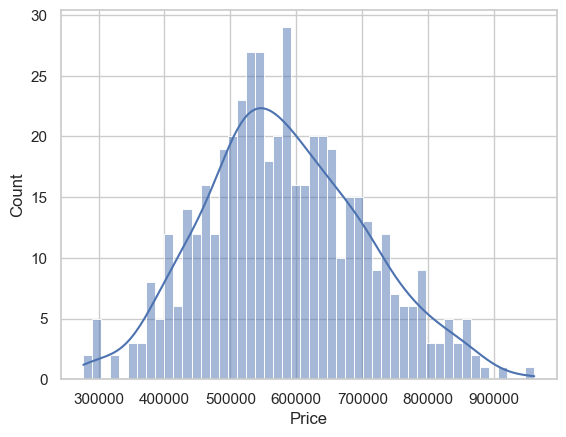

In [167]:
#Plotting the distribution of target variable
sns.histplot(df['Price'], kde= True, bins = 50)
plt.show()

#The target variable (Price) shows an approximately normal distribution with a slight positive skew. 
# Most properties are concentrated between 500,000 and 700,000, with a few higher-priced outliers extending toward 900,000. 
# Since the distribution is close to normal, transformation is not strictly required, though a log transformation may be tested to improve model performance.
# Overall, the distribution is suitable for regression modeling.

In [168]:
#Correlation matrix
df.corr()

,Square_Feet,Num_Bedrooms,Num_Bathrooms,Num_Floors,Year_Built,Has_Garden,Has_Pool,Garage_Size,Location_Score,Distance_to_Center,Price
Square_Feet,1.000000,-0.049918,-0.001667,0.056873,-0.055062,-0.000978,0.007530,-0.051598,-0.035270,0.093080,0.558604
Num_Bedrooms,-0.049918,1.000000,-0.056808,0.009088,0.031806,0.017429,0.012039,-0.065481,-0.000357,0.040511,0.563973
Num_Bathrooms,-0.001667,-0.056808,1.000000,-0.040895,-0.013407,-0.037040,-0.024880,0.055707,-0.013855,-0.082571,0.156689
Num_Floors,0.056873,0.009088,-0.040895,1.000000,0.046922,0.033256,-0.045630,-0.082763,0.019928,0.035164,0.177435
Year_Built,-0.055062,0.031806,-0.013407,0.046922,1.000000,0.000693,-0.065056,-0.008105,0.009614,-0.015113,0.418293
Has_Garden,-0.000978,0.017429,-0.037040,0.033256,0.000693,1.000000,-0.087085,-0.037998,0.019130,0.040305,0.109196
Has_Pool,0.007530,0.012039,-0.024880,-0.045630,-0.065056,-0.087085,1.000000,0.011477,-0.088722,0.110382,0.136579
Garage_Size,-0.051598,-0.065481,0.055707,-0.082763,-0.008105,-0.037998,0.011477,1.000000,-0.029939,-0.061407,0.032100
Location_Score,-0.035270,-0.000357,-0.013855,0.019928,0.009614,0.019130,-0.088722,-0.029939,1.000000,0.054446,0.071326
Distance_to_Center,0.093080,0.040511,-0.082571,0.035164,-0.015113,0.040305,0.110382,-0.061407,0.054446,1.000000,0.000730


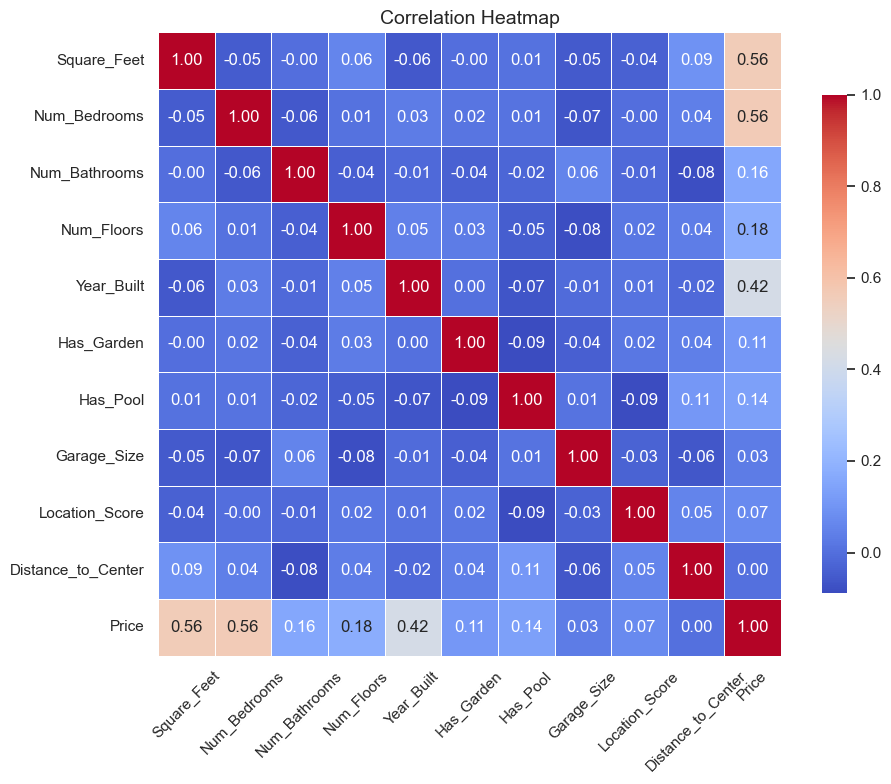

In [169]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",              # limit decimals
    cmap="coolwarm",        # better contrast
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Heatmap", fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# The correlation analysis reveals that Square_Feet and Num_Bedrooms are the most influential features, both showing a strong positive correlation (0.56) with the target variable Price. 
# Year_Built also exhibits a moderate positive correlation (0.42), indicating that newer properties tend to have higher prices. 
# Other features such as Num_Bathrooms, Num_Floors, and amenities like Has_Pool and Has_Garden show weaker but positive relationships. 
# Interestingly, Location_Score and Distance_to_Center show very weak correlations with price, suggesting limited influence in this dataset. 
# Additionally, no significant multicollinearity is observed among independent variables, making the dataset suitable for regression modeling.

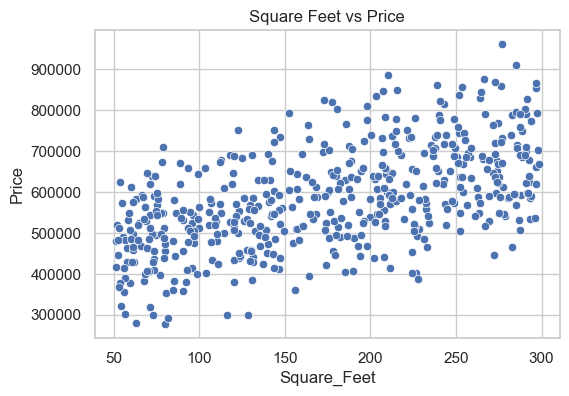

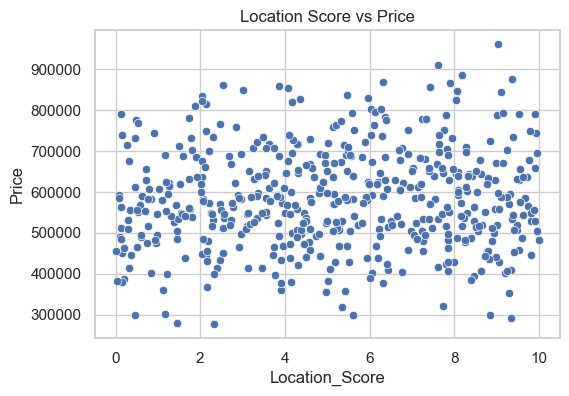

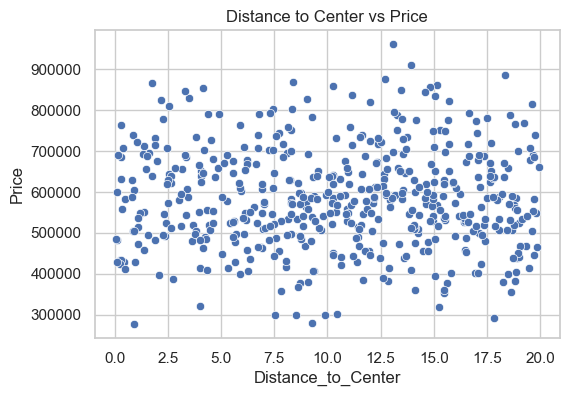

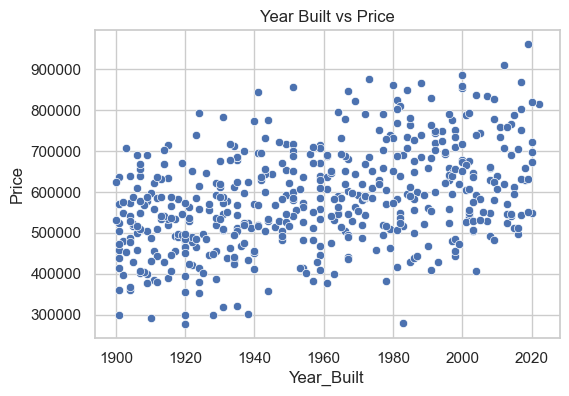

In [170]:
#Feature vs Target Relationship
sns.set(style="whitegrid")

# 1. Square_Feet vs Price
plt.figure(figsize=(6, 4))
sns.scatterplot(x='Square_Feet', y='Price', data=df)
plt.title("Square Feet vs Price")
plt.show()

# 2. Location_Score vs Price
plt.figure(figsize=(6, 4))
sns.scatterplot(x='Location_Score', y='Price', data=df)
plt.title("Location Score vs Price")
plt.show()

# 3. Distance_to_Center vs Price
plt.figure(figsize=(6, 4))
sns.scatterplot(x='Distance_to_Center', y='Price', data=df)
plt.title("Distance to Center vs Price")
plt.show()

# 4. Year_Built vs Price
plt.figure(figsize=(6, 4))
sns.scatterplot(x='Year_Built', y='Price', data=df)
plt.title("Year Built vs Price")
plt.show()

<Axes: xlabel='Garage_Size', ylabel='Price'>

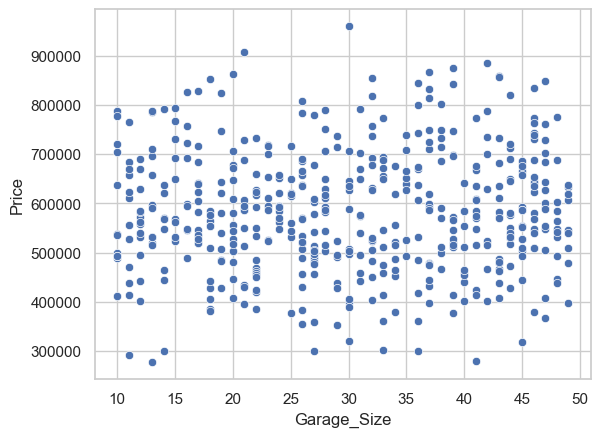

In [171]:
# Garage Size vs Price
sns.scatterplot(x='Garage_Size', y='Price', data=df)

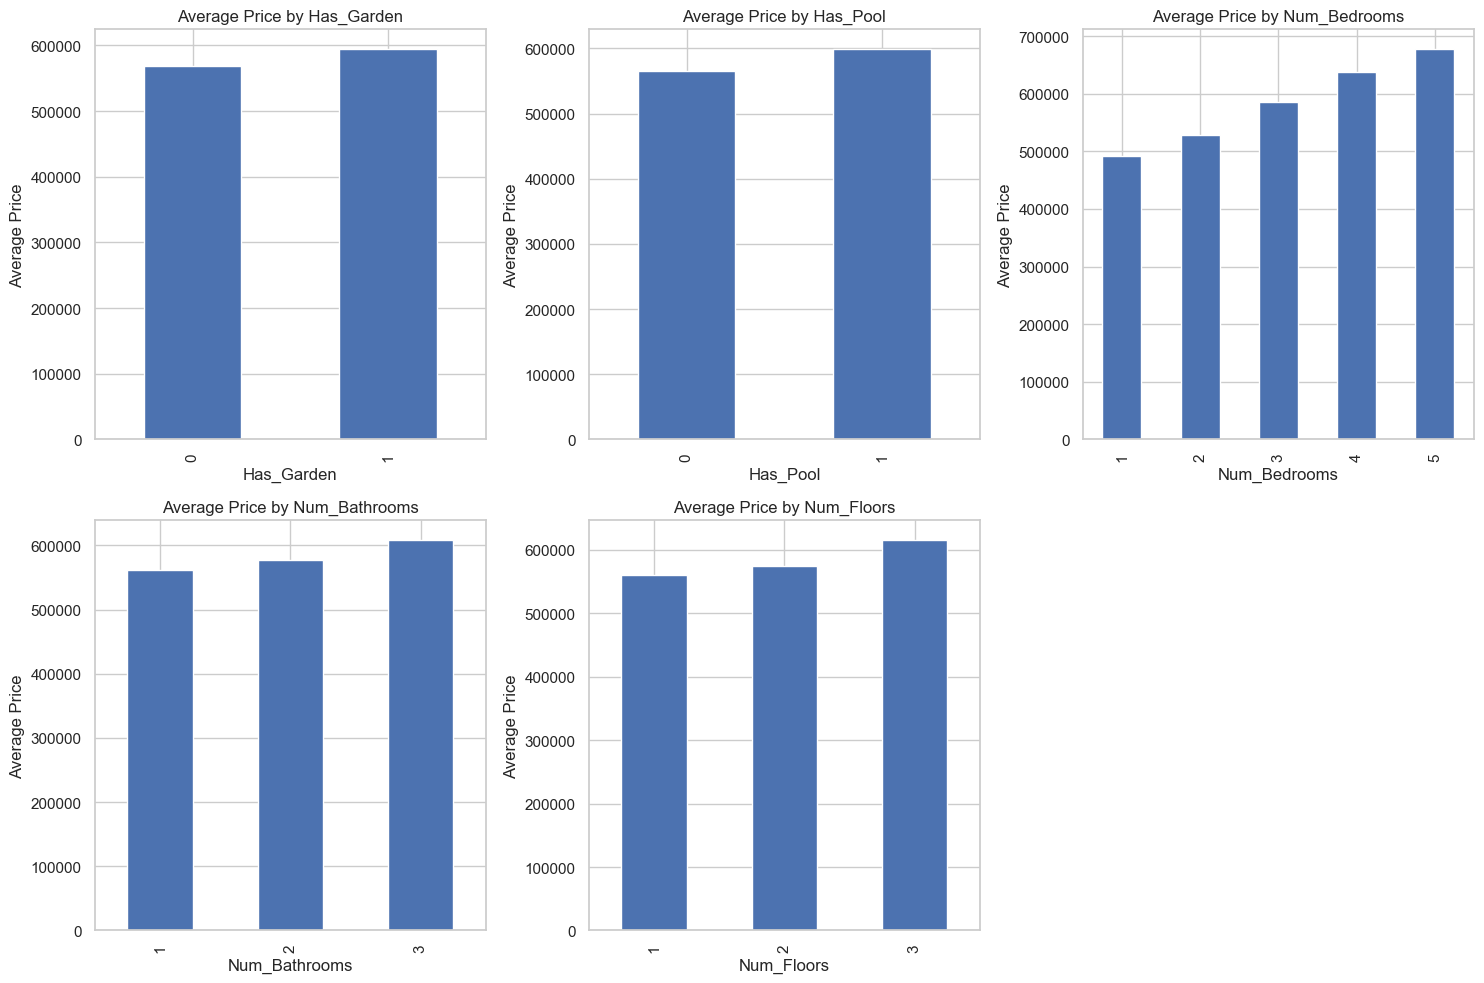

In [172]:
# Viewing the relationship between numerical features which act as categorical vs average price
features = [
    'Has_Garden',
    'Has_Pool',
    'Num_Bedrooms',
    'Num_Bathrooms',
    'Num_Floors'
]

plt.figure(figsize=(15, 10))

for i, feature in enumerate(features, 1):
    plt.subplot(2, 3, i)
    df.groupby(feature)['Price'].mean().plot(kind='bar')
    plt.title(f"Average Price by {feature}")
    plt.ylabel("Average Price")

plt.tight_layout()
plt.show()

# The analysis of discrete and categorical features shows that the number of bedrooms has the strongest impact on house prices, with a clear increasing trend as bedroom count rises. 
# Similarly, the number of bathrooms and floors exhibit positive relationships, though with lesser influence. Properties with additional amenities such as pools and gardens tend to have higher average prices, 
# with pools showing a more noticeable effect. However, garage size does not demonstrate a clear pattern with price, indicating weak predictive significance.

In [173]:
# Checking for outlier values in price
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Price'] < lower_bound) | (df['Price'] > upper_bound)]
print("Number of outliers:", len(outliers))

Number of outliers: 1


<Axes: ylabel='Price'>

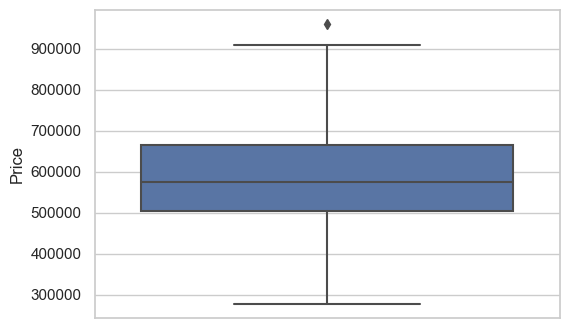

In [174]:
plt.figure(figsize=(6, 4))
sns.boxplot(y=df['Price'])

### Feature Engineering

In [175]:
# Creating new column 'House_Age'
df['House_Age'] = 2026 - df['Year_Built']

##### Creating three regression models - Baseline model with strongest correlated features, another with added moderate correlated features and last with all the features

## *First Model - Only most correlated features*

In [176]:
features = ['Square_Feet', 'Num_Bedrooms', 'House_Age']
X = df[features]
y = df['Price']

In [177]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [178]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [179]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [180]:
model.fit(X_train, y_train)

LinearRegression()

In [181]:
y_pred = model.predict(X_test)

In [182]:
from sklearn.metrics import mean_squared_error, r2_score

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 54580.53618389386
R2 Score: 0.8019500384488143


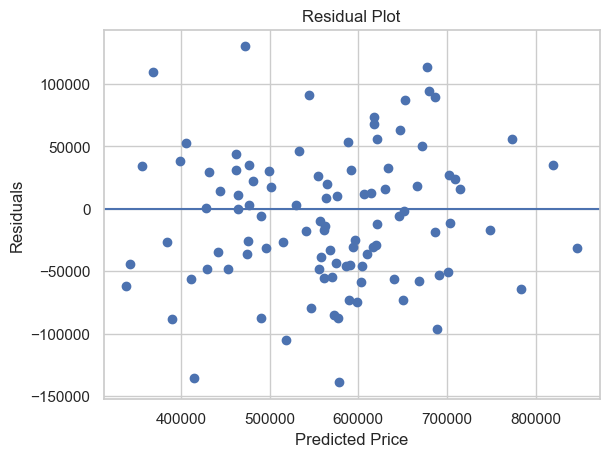

In [183]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [184]:
results = []

results.append({
    "Model": "Baseline Model(Three Features)",
    "RMSE": rmse,
    "R2": r2
})

## *Second model - Added moderate correlated features*

In [185]:
# Selecting only the valuable features
features = ['Square_Feet', 'Num_Bedrooms', 'House_Age', 'Num_Bathrooms', 'Num_Floors', 'Has_Pool', 'Has_Garden']
X = df[features]
y = df['Price']

In [186]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [187]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [188]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [189]:
y_pred = model.predict(X_test_scaled)

In [190]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 31004.531055389303
R2 Score: 0.9360928425299057


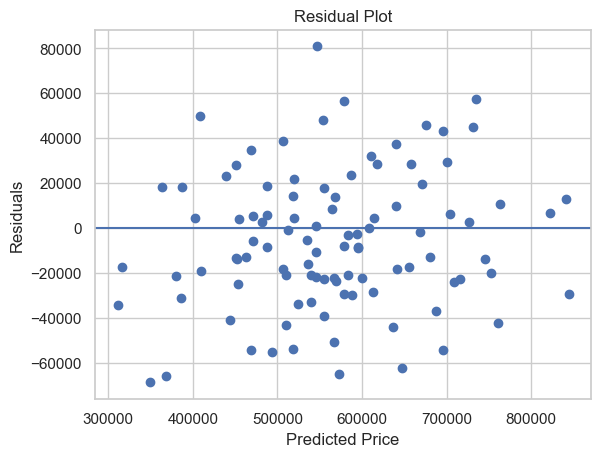

In [191]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [192]:
results.append({
    "Model": "Added Features",
    "RMSE": rmse,
    "R2": r2
})

## *Third Model - Using all the features*

In [193]:
X = df.drop('Price', axis = 1)
y = df['Price']

In [194]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size= 0.20, random_state= 42)

In [195]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

In [196]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [197]:
y_pred = model.predict(X_test_scaled)

In [198]:
rmse_all = np.sqrt(mean_squared_error(y_test, y_pred))
r2_all = r2_score(y_test, y_pred)

print("RMSE (All Features):", rmse_all)
print("R2 Score (All Features):", r2_all)

RMSE (All Features): 21020.125133153277
R2 Score (All Features): 0.9706255488274916


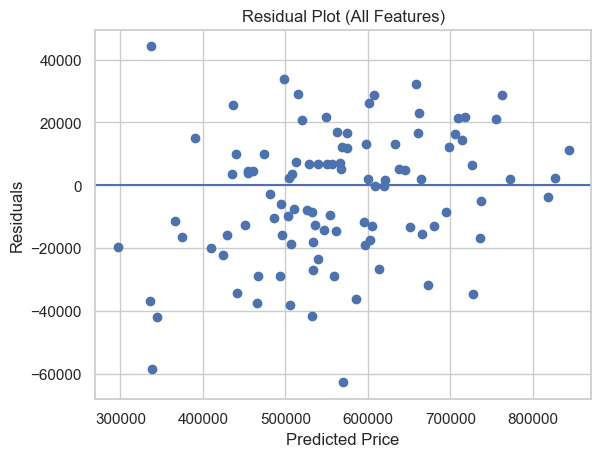

In [199]:
residuals_all = y_test - y_pred

plt.scatter(y_pred, residuals_all)
plt.axhline(y=0)
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot (All Features)")
plt.show()

In [200]:
results.append({
    "Model": "All Features",
    "RMSE": rmse_all,
    "R2": r2_all
})

### Final Comparison

In [202]:
results_df = pd.DataFrame(results)
results_df

,Model,RMSE,R2
0,Baseline Model(Three Features),54580.536184,0.801950
1,Added Features,31004.531055,0.936093
2,All Features,21020.125133,0.970626


##### The baseline model achieved an R² score of 0.80, indicating that core structural features capture a significant portion of price variance. Incorporating additional features such as number of bathrooms, floors, and amenities significantly improved performance, increasing R² to 0.93. The model using all features achieved the highest performance with an R² of 0.97 and lowest RMSE, demonstrating that even features with weaker individual correlations contribute positively when combined. This highlights the importance of comprehensive feature utilization in regression modeling.